In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [4]:
df = pd.read_csv("Unemployment in India.csv")
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    str    
 1    Date                                     740 non-null    str    
 2    Frequency                                740 non-null    str    
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    str    
dtypes: float64(3), str(4)
memory usage: 66.1 KB


In [6]:
df.shape

(768, 7)

In [7]:
df.isnull().sum()

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

In [8]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [9]:
df.columns = df.columns.str.strip()

In [10]:
df["Date"] = pd.to_datetime(df["Date"])

C:\Users\Admin\AppData\Local\Temp\ipykernel_22916\936118274.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Date"] = pd.to_datetime(df["Date"])


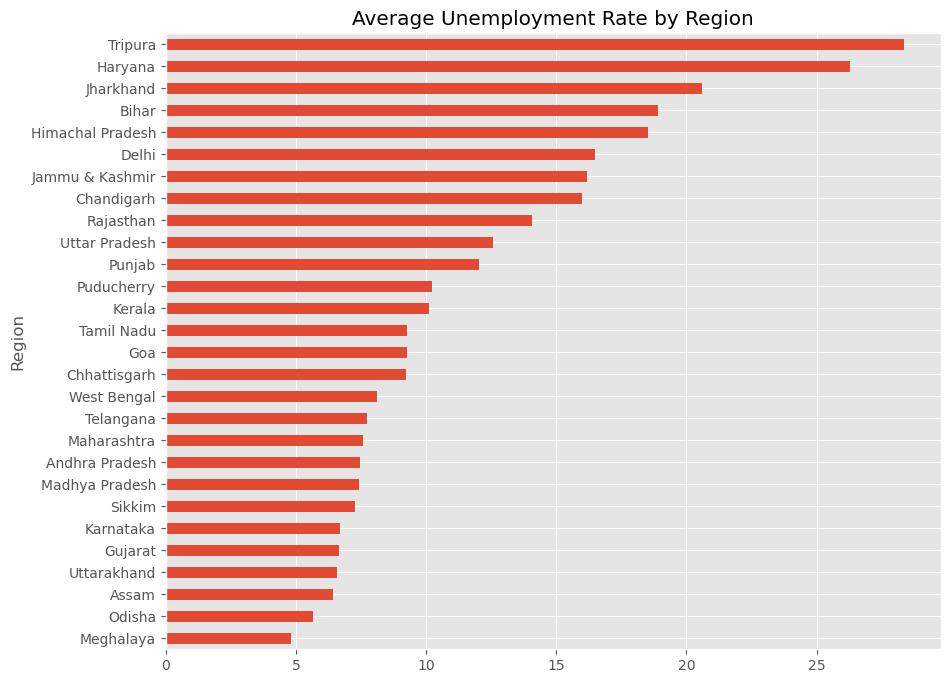

In [11]:
region_avg = df.groupby("Region")["Estimated Unemployment Rate (%)"].mean().sort_values()

plt.figure(figsize=(10,8))
region_avg.plot(kind="barh")
plt.title("Average Unemployment Rate by Region")
plt.show()

This chart shows the average unemployment rate across different regions. Some regions have significantly higher unemployment than others.

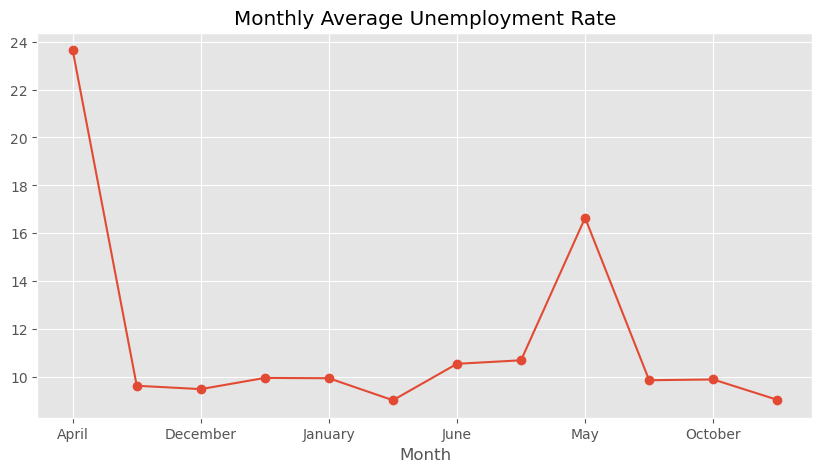

In [12]:
df["Month"] = df["Date"].dt.month_name()

month_avg = df.groupby("Month")["Estimated Unemployment Rate (%)"].mean()

month_avg.plot(figsize=(10,5),marker="o")
plt.title("Monthly Average Unemployment Rate")
plt.show()

The unemployment rate changes throughout the year. Certain months experienced noticeable increases.

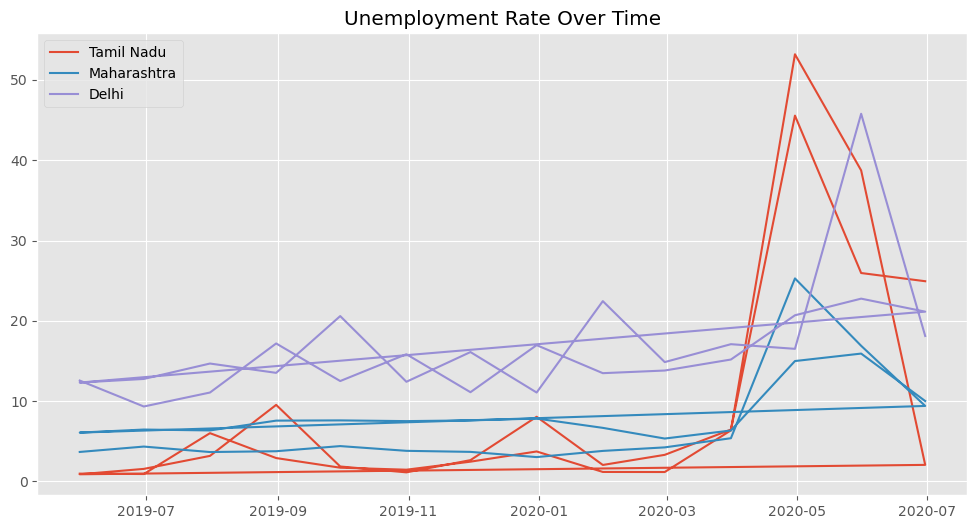

In [13]:
states = ["Tamil Nadu","Maharashtra","Delhi"]

plt.figure(figsize=(12,6))

for state in states:
    temp = df[df["Region"]==state]
    plt.plot(temp["Date"],temp["Estimated Unemployment Rate (%)"],label=state)

plt.legend()
plt.title("Unemployment Rate Over Time")
plt.show()

This line chart compares unemployment trends across three major states over time.

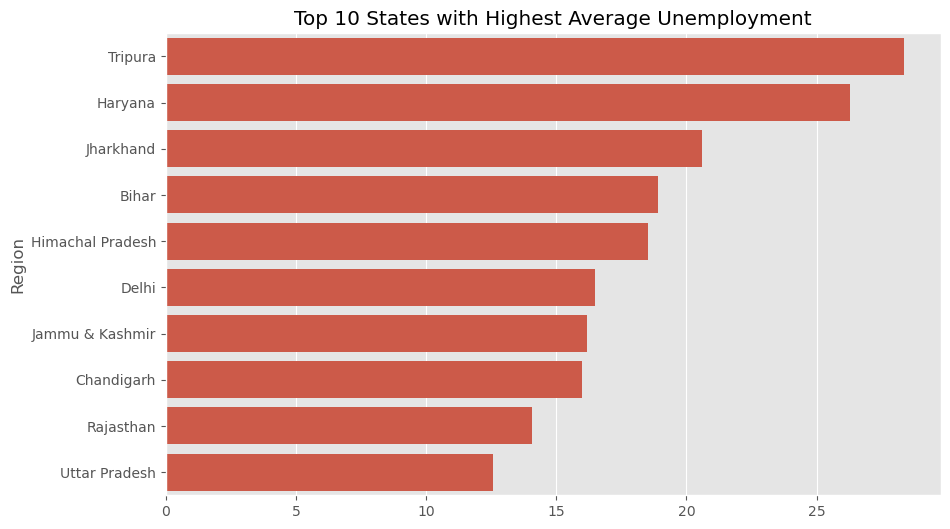

In [14]:
top10 = df.groupby("Region")["Estimated Unemployment Rate (%)"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top10.values,y=top10.index)
plt.title("Top 10 States with Highest Average Unemployment")
plt.show()

These states recorded the highest average unemployment rates in the dataset.

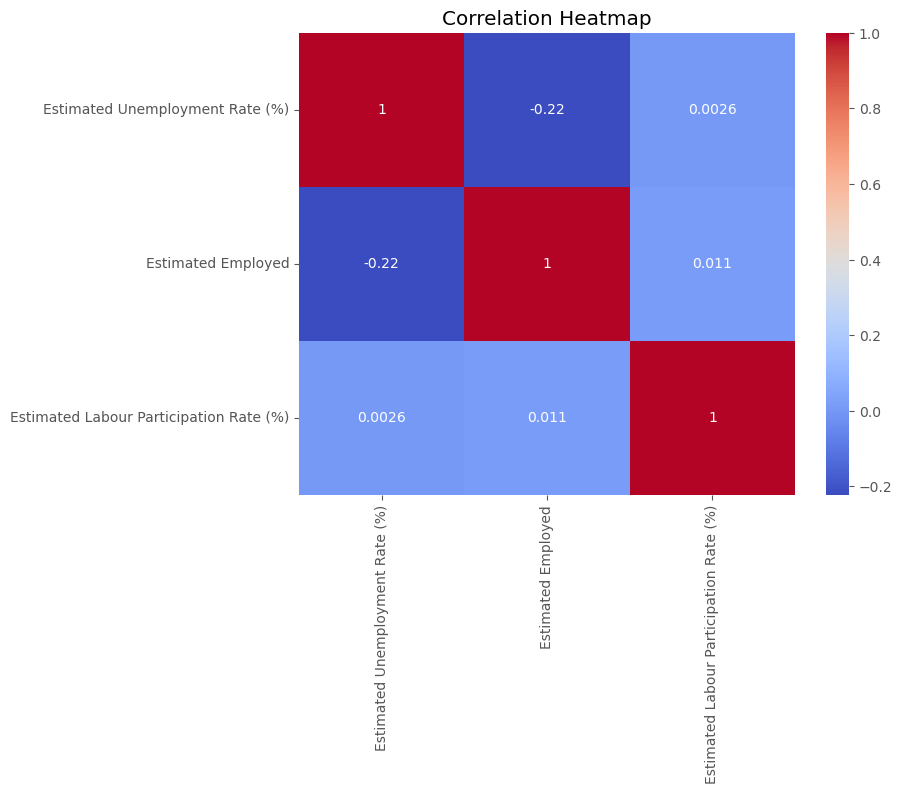

In [15]:
plt.figure(figsize=(8,6))

sns.heatmap(
df[[
"Estimated Unemployment Rate (%)",
"Estimated Employed",
"Estimated Labour Participation Rate (%)"
]].corr(),
annot=True,
cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

The heatmap illustrates relationships between unemployment, employment, and labour participation rate.

In [16]:
pre = df[df["Date"]<"2020-03-01"]
post = df[df["Date"]>="2020-03-01"]

print("Pre-COVID Mean:",
pre["Estimated Unemployment Rate (%)"].mean())

print("Post-COVID Mean:",
post["Estimated Unemployment Rate (%)"].mean())

Pre-COVID Mean: 9.509533582089553
Post-COVID Mean: 17.774362745098042
